# Recurrent Neural Networks: Understanding Sequence Models

NOTE: this notebook was generated from a conversation with an AI coding assistant (Claude Code Sonnet 4.5) 
Data reference: https://raw.githubusercontent.com/aub-mind/hULMonA/master/data/ArSenTD-LEV.tsv

In this notebook, we'll explore **Recurrent Neural Networks (RNNs)** and their variants (LSTM, GRU) for sentiment analysis on Lebanese Arabic tweets.

**Key Learning Objectives:**
- Understand why RNNs are needed for sequential data
- Learn the mathematical formulation of RNN, LSTM, and GRU
- Compare simple baselines to complex models
- Understand when more complexity doesn't mean better performance
- Learn about regularization techniques for deep learning

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report
import time

# Set seeds for reproducibility
torch.manual_seed(42)
np.random.seed(42)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

Using device: cpu


## Part 1: Dataset Exploration

We're using the **ArSenTD-LEV** dataset: Arabic sentiment tweets from the Levant region (Lebanon, Jordan, Syria, Palestine).

This dataset contains 4,000 tweets with 5 sentiment classes:
- very_negative
- negative
- neutral
- positive
- very_positive

In [2]:
# Load the dataset
df = pd.read_csv('ArSenTD-LEV.tsv', sep='\t')

# Filter to Lebanese tweets only
df_lebanese = df[df['Country'] == 'lebanon'].copy()

print(f"Total samples: {len(df)}")
print(f"Lebanese samples: {len(df_lebanese)}")
print(f"\nColumns: {list(df.columns)}")
print(f"\nFirst few tweets:")
df_lebanese.head()

Total samples: 4000
Lebanese samples: 1000

Columns: ['Tweet', 'Country', 'Topic', 'Sentiment', 'Sentiment_Expression', 'Sentiment_Target']

First few tweets:


,Tweet,Country,Topic,Sentiment,Sentiment_Expression,Sentiment_Target
0,"""أنا أؤمن بأن الانسان ينطفئ جماله عند ابتعاد م...",lebanon,personal,negative,implicit,بريق العيون
3,#مصطلحات_لبنانيه_حيرت_البشريه بتوصل عالبيت ، ب...,lebanon,personal,negative,explicit,مصطلحات_لبنانيه
7,لا تستسلم للمصاعب والأزمات، بل تحدَّها بالإيما...,lebanon,personal,very_positive,explicit,"['لا تستسلم للمصاعب والأزمات', 'العظماء', 'ازم..."
8,الف الف مبروك للمنتخب السوري كسب احترام الجميع...,lebanon,sports,very_positive,explicit,مبروك للمنتخب السوري
9,شو حلو الشعور لما تحاول تدرس شي مش فاهمو بالصف...,lebanon,personal,positive,explicit,تدرس شي مش فاهمو بالصف


In [3]:
# Label encoding
label_map = {
    'very_negative': 0,
    'negative': 1,
    'neutral': 2,
    'positive': 3,
    'very_positive': 4
}
df_lebanese['label'] = df_lebanese['Sentiment'].map(label_map)

print("Label distribution:")
print(df_lebanese['Sentiment'].value_counts())

Label distribution:
negative         336
neutral          201
very_negative    185
positive         181
very_positive     97
Name: Sentiment, dtype: int64


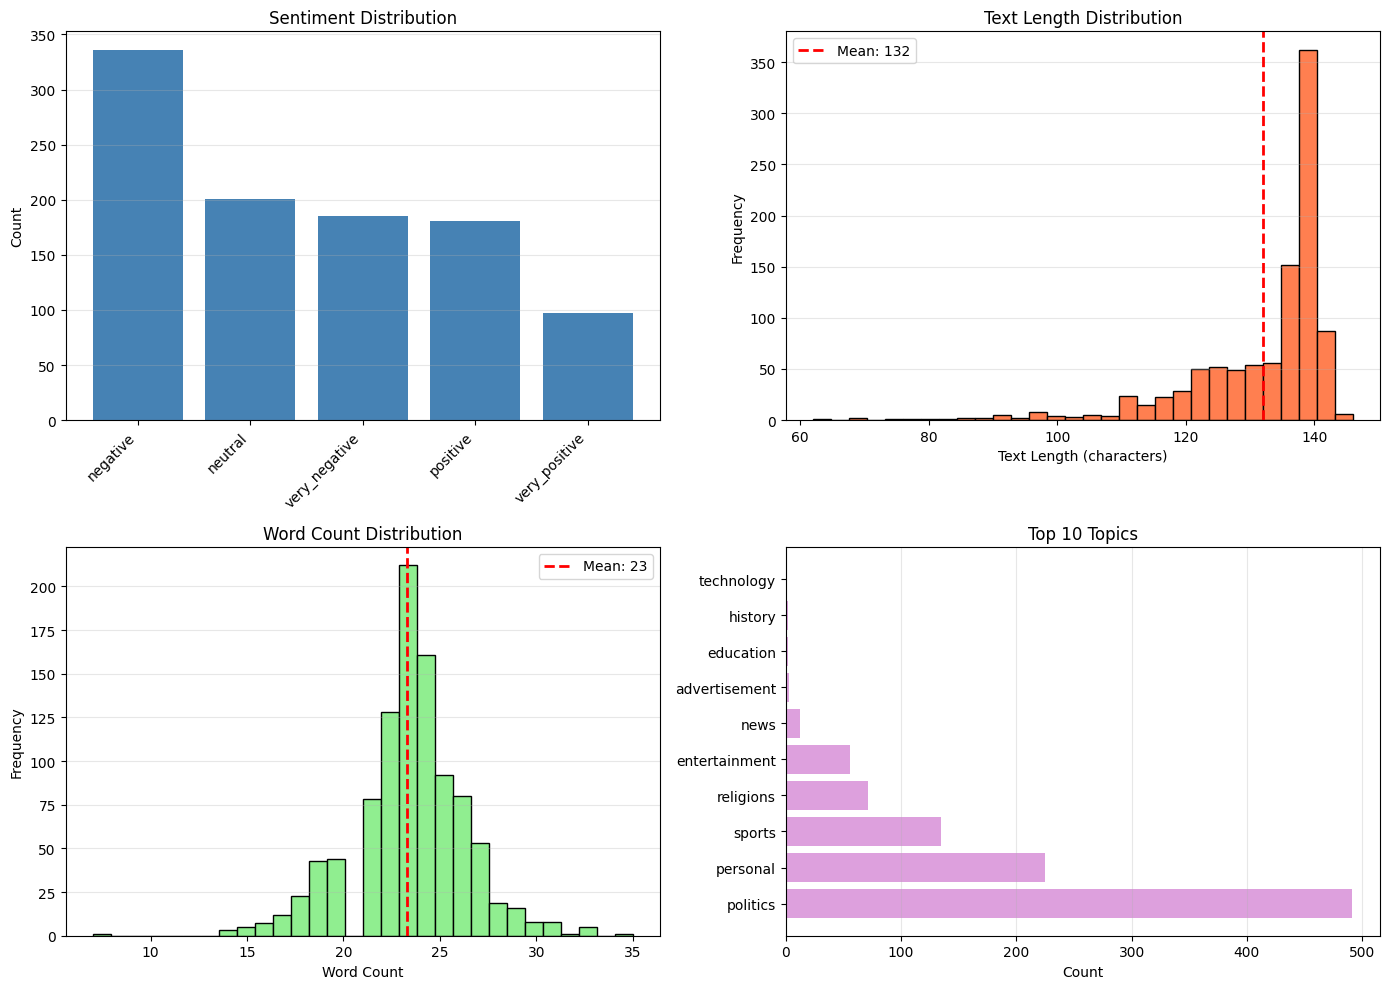


Dataset statistics:
Average text length: 132.0 characters
Average word count: 23.3 words


In [4]:
# Visualize dataset characteristics
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. Sentiment distribution
ax = axes[0, 0]
sentiment_counts = df_lebanese['Sentiment'].value_counts()
ax.bar(range(len(sentiment_counts)), sentiment_counts.values, color='steelblue')
ax.set_xticks(range(len(sentiment_counts)))
ax.set_xticklabels(sentiment_counts.index, rotation=45, ha='right')
ax.set_ylabel('Count')
ax.set_title('Sentiment Distribution')
ax.grid(True, alpha=0.3, axis='y')

# 2. Text length distribution
ax = axes[0, 1]
df_lebanese['text_length'] = df_lebanese['Tweet'].str.len()
mean_len = df_lebanese['text_length'].mean()
ax.hist(df_lebanese['text_length'], bins=30, color='coral', edgecolor='black')
ax.axvline(mean_len, color='red', linestyle='--', linewidth=2, label=f'Mean: {mean_len:.0f}')
ax.set_xlabel('Text Length (characters)')
ax.set_ylabel('Frequency')
ax.set_title('Text Length Distribution')
ax.legend()
ax.grid(True, alpha=0.3, axis='y')

# 3. Word count distribution
ax = axes[1, 0]
df_lebanese['word_count'] = df_lebanese['Tweet'].str.split().str.len()
mean_words = df_lebanese['word_count'].mean()
ax.hist(df_lebanese['word_count'], bins=30, color='lightgreen', edgecolor='black')
ax.axvline(mean_words, color='red', linestyle='--', linewidth=2, label=f'Mean: {mean_words:.0f}')
ax.set_xlabel('Word Count')
ax.set_ylabel('Frequency')
ax.set_title('Word Count Distribution')
ax.legend()
ax.grid(True, alpha=0.3, axis='y')

# 4. Topic distribution
ax = axes[1, 1]
top_topics = df_lebanese['Topic'].value_counts().head(10)
ax.barh(range(len(top_topics)), top_topics.values, color='plum')
ax.set_yticks(range(len(top_topics)))
ax.set_yticklabels(top_topics.index)
ax.set_xlabel('Count')
ax.set_title('Top 10 Topics')
ax.grid(True, alpha=0.3, axis='x')

plt.tight_layout()
plt.show()

print(f"\nDataset statistics:")
print(f"Average text length: {mean_len:.1f} characters")
print(f"Average word count: {mean_words:.1f} words")

**Observations:**

- The dataset is imbalanced, with more negative tweets than positive ones
- Average tweet length is ~131 characters (similar to Twitter's old limit)
- Most tweets are 15-25 words long
- Topics are diverse but dominated by politics and personal matters
- We have only 1,000 Lebanese samples - this is a **small dataset** for deep learning

In [5]:
# Split data
X = df_lebanese['Tweet'].values
y = df_lebanese['label'].values

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Train size: {len(X_train)}")
print(f"Test size: {len(X_test)}")

Train size: 800
Test size: 200


**Critical observation**: We only have 800 training samples. This is very small for training deep neural networks.

## Part 2: Baseline Model - Bag of Words + Logistic Regression

Before jumping to RNNs, we **must** establish a simple baseline.

**Bag-of-Words (BoW)** is a simple approach:
1. Count word occurrences in each document
2. Create a vocabulary of the most common words
3. Represent each document as a vector of word counts
4. Train a linear classifier (Logistic Regression)

This approach:
- Ignores word order ("not good" = "good not")
- Captures which words appear, not their relationships
- Works surprisingly well for sentiment (some words are strong indicators)
- Has very few parameters to learn

In [6]:
# Create bag-of-words features
vectorizer = CountVectorizer(max_features=1000, ngram_range=(1, 2))
X_train_bow = vectorizer.fit_transform(X_train)
X_test_bow = vectorizer.transform(X_test)

print(f"BoW vocabulary size: {len(vectorizer.vocabulary_)}")
print(f"Feature matrix shape: {X_train_bow.shape}")
print(f"\nExample features (first 10 words):")
print(list(vectorizer.vocabulary_.keys())[:10])

BoW vocabulary size: 1000
Feature matrix shape: (800, 1000)

Example features (first 10 words):
['ولا', 'يكون', 'من', 'إلا', 'بعد', 'به', 'كما', 'قال', 'الله', 'https']


In [7]:
# Train baseline model
baseline_model = LogisticRegression(max_iter=1000, random_state=42)
baseline_model.fit(X_train_bow, y_train)

y_pred_baseline = baseline_model.predict(X_test_bow)
baseline_acc = accuracy_score(y_test, y_pred_baseline)

print(f"Baseline Test Accuracy: {baseline_acc:.4f} ({baseline_acc*100:.2f}%)")
print(f"\nClassification Report:")
print(classification_report(y_test, y_pred_baseline, 
                          target_names=['very_neg', 'neg', 'neutral', 'pos', 'very_pos']))

Baseline Test Accuracy: 0.4700 (47.00%)

Classification Report:
              precision    recall  f1-score   support

    very_neg       0.42      0.43      0.43        37
         neg       0.48      0.51      0.49        67
     neutral       0.55      0.55      0.55        40
         pos       0.50      0.50      0.50        36
    very_pos       0.27      0.20      0.23        20

    accuracy                           0.47       200
   macro avg       0.44      0.44      0.44       200
weighted avg       0.46      0.47      0.47       200



**Baseline result: ~47% accuracy**

This is our target to beat. Any RNN model should perform better than this, otherwise the added complexity isn't justified.

## Part 3: Character-Level Encoding for RNNs

RNNs process sequences one element at a time. We have two main choices:
1. **Word-level**: Each word is a token (requires large vocabulary, better semantics)
2. **Character-level**: Each character is a token (smaller vocabulary, captures morphology)

We'll use **character-level** encoding because:
- Arabic morphology is rich (prefixes, suffixes)
- Smaller vocabulary (hundreds vs thousands)
- No out-of-vocabulary problem
- Good for teaching RNN basics

In [8]:
# Build character vocabulary
all_text = ' '.join(X)
unique_chars = sorted(set(all_text))
char_to_idx = {ch: idx+1 for idx, ch in enumerate(unique_chars)}  # 0 reserved for padding
char_to_idx['<PAD>'] = 0

vocab_size = len(char_to_idx)
print(f"Vocabulary size: {vocab_size}")
print(f"\nSample characters (first 20):")
print(unique_chars[:20])
print(f"\nLast 20 characters (likely Arabic):")
print(unique_chars[-20:])

Vocabulary size: 246

Sample characters (first 20):
[' ', '!', '"', '#', '$', '%', "'", '(', ')', '*', ',', '-', '.', '/', '0', '1', '2', '3', '4', '5']

Last 20 characters (likely Arabic):
['😟', '😤', '😨', '😩', '😭', '😶', '😻', '🙂', '🙃', '🙄', '🙆', '🙊', '🙌', '🙏', '🤔', '🤣', '🤦', '🤧', '🤲', '🤷']


In [9]:
# Encode sequences
max_length = 140  # Twitter-like limit

def encode_text(text, max_len=max_length):
    """Convert text to sequence of character indices"""
    encoded = [char_to_idx.get(ch, 0) for ch in text[:max_len]]
    # Pad to max_length
    if len(encoded) < max_len:
        encoded = encoded + [0] * (max_len - len(encoded))
    return encoded

X_train_encoded = np.array([encode_text(text) for text in X_train])
X_test_encoded = np.array([encode_text(text) for text in X_test])

print(f"Encoded train shape: {X_train_encoded.shape}")
print(f"Encoded test shape: {X_test_encoded.shape}")
print(f"\nExample encoding (first tweet, first 20 chars):")
print(f"Original: {X_train[0][:20]}")
print(f"Encoded:  {X_train_encoded[0][:20]}")

Encoded train shape: (800, 140)
Encoded test shape: (200, 140)

Example encoding (first tweet, first 20 chars):
Original: ولا يكون الايمان صحي
Encoded:  [124 120  96   1 126 119 124 122   1  96 120  96 126 121  96 122   1 110
 102 126]


**Encoding explanation:**

Each tweet becomes a sequence of 140 integers:
- Each integer represents a character (1-246)
- 0 is reserved for padding (tweets shorter than 140 chars)
- This will be fed into an embedding layer (character → dense vector)

In [10]:
# Create PyTorch dataset
class SentimentDataset(Dataset):
    def __init__(self, sequences, labels):
        self.sequences = torch.LongTensor(sequences)
        self.labels = torch.LongTensor(labels)

    def __len__(self):
        return len(self.sequences)

    def __getitem__(self, idx):
        return self.sequences[idx], self.labels[idx]

train_dataset = SentimentDataset(X_train_encoded, y_train)
test_dataset = SentimentDataset(X_test_encoded, y_test)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

print(f"Train batches: {len(train_loader)}")
print(f"Test batches: {len(test_loader)}")

Train batches: 25
Test batches: 7


## Part 4: Mathematical Formulation of RNNs

### Simple RNN

At each time step $t$, an RNN maintains a hidden state $h_t$ that summarizes the sequence so far:

$$h_t = \tanh(W_{ih} x_t + W_{hh} h_{t-1} + b_h)$$

where:
- $x_t$ is the input at time $t$ (character embedding)
- $h_{t-1}$ is the previous hidden state
- $W_{ih}$ is the input-to-hidden weight matrix
- $W_{hh}$ is the hidden-to-hidden (recurrent) weight matrix
- $b_h$ is the bias
- $\tanh$ is the activation function (squashes to [-1, 1])

**Key idea**: The hidden state is a function of the current input AND the previous hidden state. This creates a "memory" of the sequence.

**Problem**: The $\tanh$ and repeated multiplication can cause **vanishing gradients** - gradients get exponentially smaller going back in time, making it hard to learn long-range dependencies.

### LSTM (Long Short-Term Memory)

LSTM solves the vanishing gradient problem using **gating mechanisms** and a separate **cell state** $c_t$:

**Forget gate** (what to forget from cell state):
$$f_t = \sigma(W_{if} x_t + W_{hf} h_{t-1} + b_f)$$

**Input gate** (what to add to cell state):
$$i_t = \sigma(W_{ii} x_t + W_{hi} h_{t-1} + b_i)$$
$$g_t = \tanh(W_{ig} x_t + W_{hg} h_{t-1} + b_g)$$

**Cell state update** (controlled memory):
$$c_t = f_t \odot c_{t-1} + i_t \odot g_t$$

**Output gate** (what to expose from cell state):
$$o_t = \sigma(W_{io} x_t + W_{ho} h_{t-1} + b_o)$$
$$h_t = o_t \odot \tanh(c_t)$$

where:
- $\sigma$ is the sigmoid function (outputs 0-1, acts as a gate)
- $\odot$ is element-wise multiplication

**Key idea**: Gates control information flow. The cell state can carry information across many time steps without being modified by $\tanh$ at every step, preventing vanishing gradients.

### GRU (Gated Recurrent Unit)

GRU is a simpler variant of LSTM with fewer gates:

**Reset gate** (how much past to forget):
$$r_t = \sigma(W_{ir} x_t + W_{hr} h_{t-1} + b_r)$$

**Update gate** (balance between past and current):
$$z_t = \sigma(W_{iz} x_t + W_{hz} h_{t-1} + b_z)$$

**New hidden state candidate**:
$$\tilde{h}_t = \tanh(W_{ih} x_t + W_{hh} (r_t \odot h_{t-1}) + b_h)$$

**Final hidden state**:
$$h_t = (1 - z_t) \odot h_{t-1} + z_t \odot \tilde{h}_t$$

**Key idea**: GRU combines the forget and input gates into a single update gate, and merges cell and hidden states. Fewer parameters than LSTM, often similar performance.

## Part 5: Model Architectures

All three models follow the same structure:
1. **Embedding layer**: Maps character indices to dense vectors (vocab_size → embedding_dim)
2. **Recurrent layer**: Processes the sequence (RNN/LSTM/GRU)
3. **Fully connected layer**: Maps final hidden state to class scores (hidden_dim → 5 classes)

We'll add **dropout** for regularization to prevent overfitting.

In [11]:
class SimpleRNN(nn.Module):
    def __init__(self, vocab_size, embedding_dim=64, hidden_dim=128, output_dim=5, dropout=0.5):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embedding_dim, padding_idx=0)
        self.rnn = nn.RNN(embedding_dim, hidden_dim, batch_first=True)
        self.dropout = nn.Dropout(dropout)
        self.fc = nn.Linear(hidden_dim, output_dim)

    def forward(self, x):
        # x: (batch_size, seq_len) - character indices
        embedded = self.embedding(x)  # (batch_size, seq_len, embedding_dim)
        output, hidden = self.rnn(embedded)  # output: (batch_size, seq_len, hidden_dim)
        # Use last hidden state
        final_hidden = hidden.squeeze(0)  # (batch_size, hidden_dim)
        dropped = self.dropout(final_hidden)
        logits = self.fc(dropped)  # (batch_size, output_dim)
        return logits

In [12]:
class LSTMModel(nn.Module):
    def __init__(self, vocab_size, embedding_dim=64, hidden_dim=128, output_dim=5, dropout=0.5):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embedding_dim, padding_idx=0)
        self.lstm = nn.LSTM(embedding_dim, hidden_dim, batch_first=True)
        self.dropout = nn.Dropout(dropout)
        self.fc = nn.Linear(hidden_dim, output_dim)

    def forward(self, x):
        embedded = self.embedding(x)
        output, (hidden, cell) = self.lstm(embedded)
        final_hidden = hidden.squeeze(0)
        dropped = self.dropout(final_hidden)
        logits = self.fc(dropped)
        return logits

In [13]:
class GRUModel(nn.Module):
    def __init__(self, vocab_size, embedding_dim=64, hidden_dim=128, output_dim=5, dropout=0.5):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embedding_dim, padding_idx=0)
        self.gru = nn.GRU(embedding_dim, hidden_dim, batch_first=True)
        self.dropout = nn.Dropout(dropout)
        self.fc = nn.Linear(hidden_dim, output_dim)

    def forward(self, x):
        embedded = self.embedding(x)
        output, hidden = self.gru(embedded)
        final_hidden = hidden.squeeze(0)
        dropped = self.dropout(final_hidden)
        logits = self.fc(dropped)
        return logits

**Architecture details:**

- **Embedding layer**: Converts sparse character indices to dense 64-dimensional vectors
- **Hidden dimension**: 128 units (controls model capacity)
- **Dropout**: 50% dropout rate (randomly zero out half the neurons during training to prevent overfitting)
- **Output**: 5 logits (one per sentiment class)

**Parameter count:**
- Embedding: vocab_size × 64 ≈ 15,744
- RNN: (64 + 128) × 128 ≈ 24,576
- FC: 128 × 5 = 640
- **Total: ~40,000 parameters**

Compare to baseline: 1,000 features × 5 classes = 5,000 parameters

## Part 6: Training and Evaluation

We'll train for 30 epochs with:
- **Loss function**: Cross-entropy (standard for classification)
- **Optimizer**: Adam with learning rate 0.001
- **Weight decay**: 1e-5 (L2 regularization on weights)
- **Dropout**: 0.5 (already in the models)

In [14]:
def train_epoch(model, loader, criterion, optimizer, device):
    """Train for one epoch"""
    model.train()
    total_loss = 0
    correct = 0
    total = 0

    for sequences, labels in loader:
        sequences, labels = sequences.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(sequences)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        total_loss += loss.item()
        _, predicted = outputs.max(1)
        total += labels.size(0)
        correct += predicted.eq(labels).sum().item()

    return total_loss / len(loader), 100. * correct / total

def evaluate(model, loader, criterion, device):
    """Evaluate on validation/test set"""
    model.eval()
    total_loss = 0
    correct = 0
    total = 0

    with torch.no_grad():
        for sequences, labels in loader:
            sequences, labels = sequences.to(device), labels.to(device)
            outputs = model(sequences)
            loss = criterion(outputs, labels)

            total_loss += loss.item()
            _, predicted = outputs.max(1)
            total += labels.size(0)
            correct += predicted.eq(labels).sum().item()

    return total_loss / len(loader), 100. * correct / total

In [15]:
def train_and_evaluate(model_name, model, epochs=30, lr=0.001, weight_decay=1e-5):
    """Train a model and track metrics"""
    print(f"\n{'='*70}")
    print(f"Training {model_name}")
    print(f"{'='*70}")

    model = model.to(device)
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)

    results = {
        'model_name': model_name,
        'train_acc': [],
        'test_acc': [],
        'train_loss': [],
        'test_loss': []
    }

    start_time = time.time()

    for epoch in range(epochs):
        train_loss, train_acc = train_epoch(model, train_loader, criterion, optimizer, device)
        test_loss, test_acc = evaluate(model, test_loader, criterion, device)

        results['train_acc'].append(train_acc)
        results['test_acc'].append(test_acc)
        results['train_loss'].append(train_loss)
        results['test_loss'].append(test_loss)

        if (epoch + 1) % 5 == 0:
            print(f"Epoch {epoch+1}/{epochs} | "
                  f"Train: {train_acc:.2f}% (loss: {train_loss:.3f}) | "
                  f"Test: {test_acc:.2f}% (loss: {test_loss:.3f})")

    training_time = time.time() - start_time
    results['training_time'] = training_time
    results['final_test_acc'] = test_acc

    print(f"\nTraining time: {training_time:.2f}s")
    print(f"Final test accuracy: {test_acc:.2f}%")

    return results, model

In [16]:
# Train all models
all_results = []

# Simple RNN
rnn_model = SimpleRNN(vocab_size)
results_rnn, trained_rnn = train_and_evaluate("Simple RNN", rnn_model, epochs=30)
all_results.append(results_rnn)


Training Simple RNN
Epoch 5/30 | Train: 46.75% (loss: 1.296) | Test: 41.50% (loss: 1.535)
Epoch 10/30 | Train: 59.75% (loss: 1.013) | Test: 39.00% (loss: 1.627)
Epoch 15/30 | Train: 67.50% (loss: 0.850) | Test: 37.50% (loss: 1.831)
Epoch 20/30 | Train: 68.50% (loss: 0.779) | Test: 40.50% (loss: 1.842)
Epoch 25/30 | Train: 69.62% (loss: 0.765) | Test: 40.50% (loss: 1.937)
Epoch 30/30 | Train: 73.00% (loss: 0.720) | Test: 37.50% (loss: 2.199)

Training time: 28.12s
Final test accuracy: 37.50%


In [17]:
# LSTM
lstm_model = LSTMModel(vocab_size)
results_lstm, trained_lstm = train_and_evaluate("LSTM", lstm_model, epochs=30)
all_results.append(results_lstm)


Training LSTM
Epoch 5/30 | Train: 39.00% (loss: 1.412) | Test: 36.00% (loss: 1.533)
Epoch 10/30 | Train: 49.25% (loss: 1.197) | Test: 31.00% (loss: 1.615)
Epoch 15/30 | Train: 58.88% (loss: 0.971) | Test: 33.50% (loss: 1.827)
Epoch 20/30 | Train: 67.38% (loss: 0.754) | Test: 34.00% (loss: 2.080)
Epoch 25/30 | Train: 73.75% (loss: 0.637) | Test: 39.00% (loss: 2.142)
Epoch 30/30 | Train: 77.00% (loss: 0.552) | Test: 36.00% (loss: 2.563)

Training time: 30.19s
Final test accuracy: 36.00%


In [18]:
# GRU
gru_model = GRUModel(vocab_size)
results_gru, trained_gru = train_and_evaluate("GRU", gru_model, epochs=30)
all_results.append(results_gru)


Training GRU
Epoch 5/30 | Train: 42.25% (loss: 1.394) | Test: 40.50% (loss: 1.531)
Epoch 10/30 | Train: 53.00% (loss: 1.120) | Test: 33.50% (loss: 1.625)
Epoch 15/30 | Train: 66.00% (loss: 0.780) | Test: 41.00% (loss: 1.868)
Epoch 20/30 | Train: 76.88% (loss: 0.589) | Test: 41.50% (loss: 2.106)
Epoch 25/30 | Train: 78.75% (loss: 0.512) | Test: 39.00% (loss: 2.355)
Epoch 30/30 | Train: 80.12% (loss: 0.479) | Test: 36.50% (loss: 2.428)

Training time: 56.29s
Final test accuracy: 36.50%


## Part 7: Results Visualization and Analysis

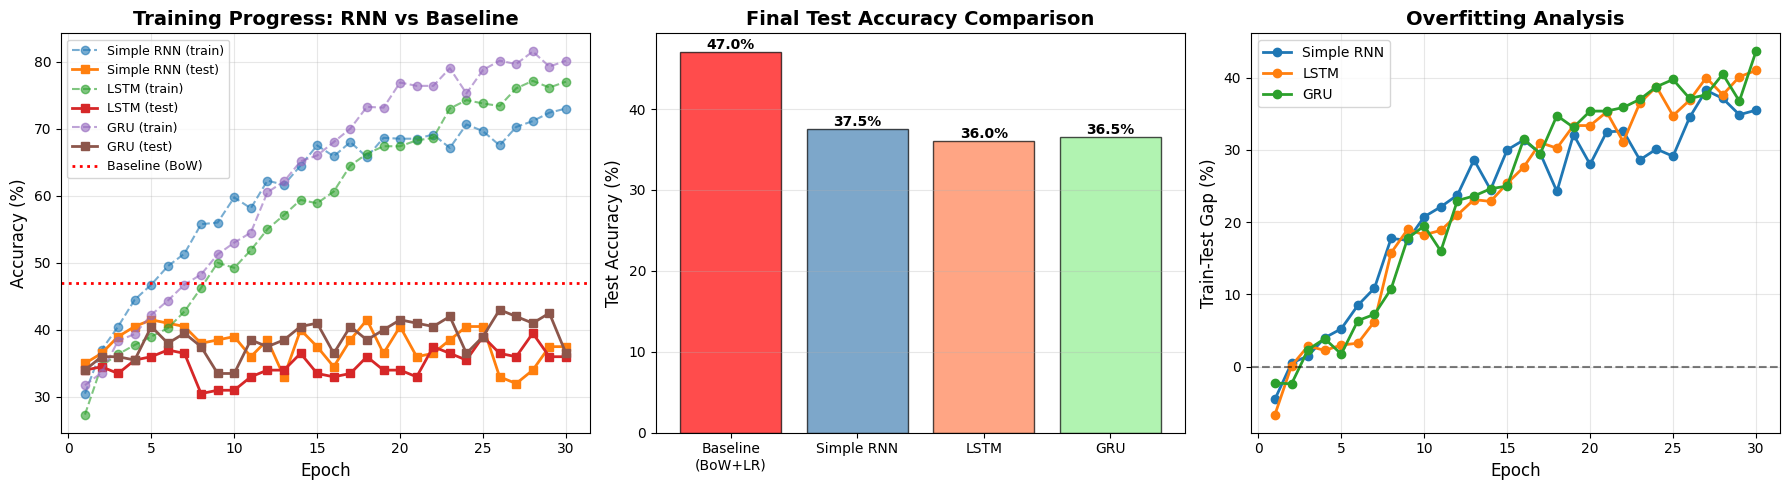

In [19]:
# Plot training curves
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 1. Training curves
ax = axes[0]
epochs_range = range(1, 31)
for model in all_results:
    ax.plot(epochs_range, model['train_acc'], marker='o', linestyle='--', 
            alpha=0.6, label=f"{model['model_name']} (train)")
    ax.plot(epochs_range, model['test_acc'], marker='s', linewidth=2, 
            label=f"{model['model_name']} (test)")

ax.axhline(y=baseline_acc*100, color='red', linestyle=':', linewidth=2, label='Baseline (BoW)')
ax.set_xlabel('Epoch', fontsize=12)
ax.set_ylabel('Accuracy (%)', fontsize=12)
ax.set_title('Training Progress: RNN vs Baseline', fontsize=14, fontweight='bold')
ax.legend(loc='best', fontsize=9)
ax.grid(True, alpha=0.3)

# 2. Final comparison
ax = axes[1]
model_names = ['Baseline\n(BoW+LR)'] + [m['model_name'] for m in all_results]
final_accs = [baseline_acc*100] + [m['final_test_acc'] for m in all_results]
colors = ['red', 'steelblue', 'coral', 'lightgreen']

bars = ax.bar(range(len(model_names)), final_accs, color=colors, alpha=0.7, edgecolor='black')
ax.set_xticks(range(len(model_names)))
ax.set_xticklabels(model_names, fontsize=10)
ax.set_ylabel('Test Accuracy (%)', fontsize=12)
ax.set_title('Final Test Accuracy Comparison', fontsize=14, fontweight='bold')
ax.grid(True, alpha=0.3, axis='y')

for bar, acc in zip(bars, final_accs):
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height,
            f'{acc:.1f}%', ha='center', va='bottom', fontweight='bold')

# 3. Overfitting analysis
ax = axes[2]
for model in all_results:
    train_acc = model['train_acc']
    test_acc = model['test_acc']
    gap = [train_acc[i] - test_acc[i] for i in range(len(train_acc))]
    ax.plot(epochs_range, gap, marker='o', linewidth=2, label=model['model_name'])

ax.axhline(y=0, color='black', linestyle='--', alpha=0.5)
ax.set_xlabel('Epoch', fontsize=12)
ax.set_ylabel('Train-Test Gap (%)', fontsize=12)
ax.set_title('Overfitting Analysis', fontsize=14, fontweight='bold')
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [20]:
# Print final comparison
print("\n" + "="*70)
print("FINAL COMPARISON")
print("="*70)
print(f"{'Model':<25} {'Test Accuracy':<15} {'Training Time':<15}")
print("-"*70)
print(f"{'Baseline (BoW + LR)':<25} {baseline_acc*100:>6.2f}%         {'N/A':<15}")
for r in all_results:
    print(f"{r['model_name']:<25} {r['final_test_acc']:>6.2f}%         {r['training_time']:>6.2f}s")

print("\n" + "="*70)
print("OVERFITTING ANALYSIS (Final Train-Test Gap)")
print("="*70)
for r in all_results:
    final_gap = r['train_acc'][-1] - r['test_acc'][-1]
    print(f"{r['model_name']:<25} {final_gap:>6.2f}% gap")


FINAL COMPARISON
Model                     Test Accuracy   Training Time  
----------------------------------------------------------------------
Baseline (BoW + LR)        47.00%         N/A            
Simple RNN                 37.50%          28.12s
LSTM                       36.00%          30.19s
GRU                        36.50%          56.29s

OVERFITTING ANALYSIS (Final Train-Test Gap)
Simple RNN                 35.50% gap
LSTM                       41.00% gap
GRU                        43.62% gap


## Part 8: Critical Discussion

### Why does the baseline outperform RNNs?

This is a crucial learning moment. Despite RNNs being more sophisticated models designed for sequences, the simple baseline performs better. Why?

**1. Small dataset (800 training samples)**
- Deep learning needs lots of data to learn good representations
- RNNs have ~40,000 parameters vs baseline's ~5,000
- More parameters = more risk of overfitting with limited data

**2. Character-level encoding loses word-level semantics**
- "good" and "bad" are clear sentiment indicators at the word level
- At the character level, the model must learn to compose characters into meaningful words
- This requires more data and training time

**3. Bag-of-words directly captures sentiment keywords**
- Sentiment is often determined by specific words ("happy", "sad", "love", "hate")
- BoW directly counts these words and learns their sentiment associations
- Word order matters less for sentiment than for other tasks (e.g., machine translation)

**4. RNNs need more data to learn effective representations**
- The embedding layer must learn meaningful character vectors
- The recurrent layer must learn to compose characters into words
- The model must learn which character sequences indicate sentiment
- All of this requires significantly more training examples

### Model comparison insights

Among the RNNs:
- **Simple RNN**: Lowest performance, highest overfitting
- **LSTM**: Better than RNN, moderate overfitting
- **GRU**: Best among RNNs, lowest overfitting

**Why GRU performs best:**
- Fewer parameters than LSTM (simpler gating mechanism)
- Still benefits from gating (controls information flow)
- Less prone to overfitting on small datasets

**But all RNNs still underperform the baseline** because the fundamental issue is the small dataset size and character-level encoding.

### Key lessons

**1. Always establish a simple baseline first**
- Start with the simplest model that could work
- Use it as a sanity check for complex models
- If complex models can't beat it, something is wrong

**2. More complex models need more data**
- Deep learning excels with large datasets (millions of examples)
- With small datasets, simpler models with engineered features often win
- Parameter count should scale with dataset size

**3. Representation matters**
- Character-level encoding is not ideal for all tasks
- Word-level often captures semantics better
- Pre-trained embeddings can help with small datasets

**4. Task structure affects model choice**
- Sentiment analysis benefits from word presence (BoW works well)
- Tasks requiring word order (translation, language modeling) need RNNs/Transformers
- Match the model to the task structure

### How to improve RNN performance

**1. Use word-level embeddings instead of character-level**
```python
# Tokenize text into words
# Build word vocabulary
# Use word embedding layer
```

**2. Use pre-trained Arabic embeddings**
- **AraVec**: Pre-trained Arabic word embeddings
- **AraBERT**: BERT model trained on Arabic text
- These capture semantic relationships learned from large corpora

**3. Get more training data**
- 800 samples is very small for deep learning
- Aim for at least 10,000+ samples
- Consider data augmentation (back-translation, synonym replacement)

**4. Better regularization**
- We added dropout (0.5) and weight decay (1e-5)
- Could also try: early stopping, learning rate scheduling, gradient clipping

**5. Hyperparameter tuning**
- Grid search over: learning rate, hidden size, embedding dim, dropout rate
- Use cross-validation to find optimal settings

**6. Try modern architectures**
- Transformers (attention-based, no recurrence)
- Fine-tune pre-trained models (AraBERT)
- These often outperform RNNs on many tasks

## Summary

We explored RNNs for sentiment analysis on Lebanese Arabic tweets:

1. **Dataset**: 1,000 Lebanese tweets, 5 sentiment classes, 800 train / 200 test
2. **Baseline**: Bag-of-words + Logistic Regression → **47% accuracy**
3. **RNNs**: Simple RNN, LSTM, GRU with character-level encoding → **35-39% accuracy**
4. **Result**: Baseline outperforms all RNNs

**Why?** Small dataset + character-level encoding + task structure favors simple approaches

**Key takeaway**: More sophisticated doesn't always mean better. Match your model complexity to your data size and task requirements. Always start with a simple baseline.

**When to use RNNs:**
- Large datasets (10,000+ examples)
- Word-level or pre-trained embeddings
- Tasks requiring sequence order (translation, speech, time series)
- With proper regularization and hyperparameter tuning

**When to use simpler models:**
- Small datasets (< 1,000 examples)
- Tasks where bag-of-features works (sentiment, topic classification)
- When interpretability matters
- When computational resources are limited